# 05 三类日波动代理：RV、MedRV 与 Parkinson

本 Notebook 在固定三个月交割合约链上，直接从正式 silver 一分钟事实重新构造五分钟收益与仅日盘的日最高/最低价，并计算论文用于样本外评价的三类日方差代理。

## 1. 在做什么，以及经济意义

真实波动率不可直接观测，预测比较必须先选一个可观测的“真值代理”。三个代理使用的信息和稳健性不同：

- **五分钟实现方差（RV）**：加总全部五分钟平方收益，最直接利用盘中路径，但孤立跳跃或异常大收益会显著放大它。
- **median-based 方差（MedRV）**：对相邻三个绝对收益取中位数后平方，降低孤立跳跃和大量很小/零收益的影响。
- **Parkinson 方差**：只用当日日盘最高价与最低价；在连续扩散等经典假设下，价格区间比单一收盘收益更有效率，但它依赖高低价质量且不会区分跳跃与连续波动。

经济上，三者的差异不是谁必然“正确”，而是测量误差与市场微观结构敏感性不同。后续 RMSFE、DM–West 与 SPA 检验会对三个代理分别评价同一组模型，避免结论只由单一代理驱动。

## 2. 论文公式、表图对应与当前复现等级

论文第 2.2 节公式 (4)–(6) 定义三类日方差代理。当前真实日盘每个完整交易日有 $N=45$ 个五分钟收益，而不是论文原样本的 48 个：

$$\widehat{\sigma}^{2}_{rv,t}=\sum_{n=1}^{N}r_{t,n}^{2}.$$

$$\widehat{\sigma}^{2}_{med,t}=\frac{\pi}{6-4\sqrt{3}+\pi}\left(\frac{N}{N-2}\right)\sum_{n=2}^{N-1}\operatorname{med}(|r_{t,n-1}|,|r_{t,n}|,|r_{t,n+1}|)^2.$$

因此本项目的 MedRV 每日必须恰有 $N-2=43$ 个中位数项，并保留 $N/(N-2)=45/43$ 的有限样本修正。相邻关系只在同一交易日的 45 个五分钟收益内建立，不跨日；三个真实 Session 的长度都能被五分钟整除，因此五分钟收益本身也不跨休市。

Parkinson 基线采用经典公式：

$$\widehat{\sigma}^{2}_{rng,t}=\frac{[\log(H_t/L_t)]^2}{4\log 2}.$$

论文 PDF 的公式 (6) 视觉括号把 $1/(4\log 2)$ 与对数区间一起置于平方内；若逐字执行会把系数也平方，与经典 Parkinson 估计量不一致。本项目遵守 README 已冻结的经典公式，并把该差异作为排版歧义披露。$H_t$、$L_t$ 从精确选中的 225 个真实日盘分钟 high/low 聚合，不读取包含其他时段的日线高低价。

这些代理在论文 Table 7 的 RMSFE、Tables 8/10–12 的 DM–West 比较、Table 9 的 SPA 检验中分别作为真值；Figure 2 使用 median-based 代理展示预测误差。本项只完成代理构造、比较与门禁，不提前执行预测评价。复现等级为 **论文方法框架复现**，不声称复制 GTA 数值。

In [1]:
from __future__ import annotations

from datetime import date
import gc
import pathlib
import sys
import time

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        project_root = candidate_root
        break
else:
    raise RuntimeError("未找到项目根目录")

expected_python = pathlib.Path(r"E:\anaconda3\envs\latitude\python.exe").resolve()
current_python = pathlib.Path(sys.executable).resolve()
assert current_python == expected_python, (
    f"必须使用 latitude 环境解释器 {expected_python}，实际为 {current_python}"
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
from IPython.display import Markdown, display

from config.data_contracts import (
    FUTURES_BAR_CALENDAR_SCHEMA,
    FUTURES_CONTRACT_CALENDAR_SCHEMA,
    FUTURES_MINUTE_SCHEMA,
    FUTURES_VARIETY_CALENDAR_SCHEMA,
    arrow_to_pandas,
    validate_arrow_table,
)
from config.notebook_schema_browser import display_schema_metadata
from config.settings import settings

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 200)

print(f"Python: {sys.executable}")
print(f"项目根目录: {project_root}")
print(f"正式湖仓根目录: {settings.futures_lake_root}")

Python: E:\anaconda3\envs\latitude\python.exe
项目根目录: E:\Latitude_Analytics_v2
正式湖仓根目录: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake


## 3. 开篇 Schema metadata 浏览器

以下浏览器直接投影权威 Schema；表名、主键、分区、字段类型与 nullable 不在 Notebook 另建契约。

In [2]:
display_schema_metadata(
    [
        FUTURES_VARIETY_CALENDAR_SCHEMA,
        FUTURES_CONTRACT_CALENDAR_SCHEMA,
        FUTURES_BAR_CALENDAR_SCHEMA,
        FUTURES_MINUTE_SCHEMA,
    ]
)

英文表名,中文表名,字段数,主键,Hive 分区,Schema 版本
dim_futures_variety_calendar,期货品种交易日历维度表,8,"exchange_code,underlying_code,trading_date","exchange_code,year,month",1.2.0
dim_futures_contract_calendar,期货合约 Session 日历维度表,21,"contract_code,trading_date,session_number","exchange_code,year,month",1.2.0
dim_futures_bar_calendar,期货行情拉取与质检日历维度表,48,"bar_frequency,contract_code,trading_date,session_number","bar_frequency,exchange_code,year,month",1.4.0
fact_futures_minute,国内期货合约一分钟行情事实表,17,"contract_code,bar_at","exchange_code,underlying_code,year,month",1.5.0


## 4. 参数、固定样本与代码步骤

代码保持线性、自包含：

1. 从品种与合约 Session 日历重建“交易月后第 3 个月交割”链。
2. 用一分钟 bar 日历限定 3 个完整日盘 Session 和 225 个事实分钟。
3. 每个 Session 首分钟以自身 open 锚定，随后以上一分钟 close 构造收益；按真实交易分钟顺序聚合 45 个五分钟收益。
4. 计算 RV、含一致性常数与有限样本修正的 MedRV，以及仅日盘高低价的经典 Parkinson 方差。
5. 分别检查有效分母、有限性、非负性、手工公式与五个研究序列边界；比较尺度、比率与相关性。

In [3]:
exchange_code = "XSGE"
sample_start = date(2010, 1, 4)
sample_end = date(2026, 8, 28)
expected_day_sessions = 3
expected_day_minutes = 225
five_minute_interval = 5
expected_five_minute_slots = 45
expected_medrv_terms = expected_five_minute_slots - 2
zero_return_tolerance = 1e-12

medrv_consistency_constant = (
    np.pi / (6 - 4 * np.sqrt(3) + np.pi)
)
medrv_finite_sample_multiplier = (
    expected_five_minute_slots / expected_medrv_terms
)
medrv_total_multiplier = (
    medrv_consistency_constant * medrv_finite_sample_multiplier
)

sample_spec_df = pd.DataFrame(
    [
        ("AL", "AL", date(2010, 1, 4), date(2026, 8, 28), "论文品种"),
        ("CU", "CU", date(2010, 1, 4), date(2026, 8, 28), "论文品种"),
        ("FU_legacy", "FU", date(2010, 1, 4), date(2011, 9, 30), "论文品种：旧产品段"),
        ("FU_relaunched", "FU", date(2020, 1, 2), date(2026, 8, 28), "论文品种：稳定重启段"),
        ("RB", "RB", date(2010, 1, 4), date(2026, 8, 28), "论文外扩展品种"),
    ],
    columns=[
        "series_id",
        "underlying_code",
        "sample_start",
        "sample_end",
        "research_role",
    ],
)
sample_spec_df["sample_start"] = pd.to_datetime(sample_spec_df["sample_start"])
sample_spec_df["sample_end"] = pd.to_datetime(sample_spec_df["sample_end"])
series_order = sample_spec_df["series_id"].tolist()
proxy_columns = [
    "realized_variance",
    "median_based_variance",
    "range_based_variance",
]
proxy_label_by_column = {
    "realized_variance": "RV",
    "median_based_variance": "MedRV",
    "range_based_variance": "Parkinson",
}
proxy_order = list(proxy_label_by_column.values())

display(sample_spec_df)
display(
    pd.DataFrame(
        {
            "parameter": [
                "N",
                "N-2",
                "MedRV consistency constant",
                "MedRV finite-sample multiplier",
                "MedRV total multiplier",
            ],
            "value": [
                expected_five_minute_slots,
                expected_medrv_terms,
                medrv_consistency_constant,
                medrv_finite_sample_multiplier,
                medrv_total_multiplier,
            ],
        }
    )
)

,series_id,underlying_code,sample_start,sample_end,research_role
0,AL,AL,2010-01-04,2026-08-28,论文品种
1,CU,CU,2010-01-04,2026-08-28,论文品种
2,FU_legacy,FU,2010-01-04,2011-09-30,论文品种：旧产品段
3,FU_relaunched,FU,2020-01-02,2026-08-28,论文品种：稳定重启段
4,RB,RB,2010-01-04,2026-08-28,论文外扩展品种


,parameter,value
0,N,45.000000
1,N-2,43.000000
2,MedRV consistency constant,1.419358
3,MedRV finite-sample multiplier,1.046512
4,MedRV total multiplier,1.485375


## 5. 直接 PyArrow 过滤读取与固定三个月合约链

只读取当前项目需要的四张正式 silver 表与窄列。分区、表名和主键先从各权威 Schema metadata 解码；业务事实按交易所、品种、年份、日期和当年目标合约过滤。

In [4]:
source_schema_by_role = {
    "variety_calendar": FUTURES_VARIETY_CALENDAR_SCHEMA,
    "contract_calendar": FUTURES_CONTRACT_CALENDAR_SCHEMA,
    "bar_calendar": FUTURES_BAR_CALENDAR_SCHEMA,
    "minute_fact": FUTURES_MINUTE_SCHEMA,
}
source_dataset_by_role = {}
source_contract_audit_rows = []

for source_role, source_schema in source_schema_by_role.items():
    source_metadata = {
        key.decode("utf-8"): value.decode("utf-8")
        for key, value in source_schema.metadata.items()
    }
    table_name = source_metadata["table_name"]
    primary_key = source_metadata["primary_key"].split(",")
    partition_columns = source_metadata["partition_columns"].split(",")
    table_path = settings.futures_lake_root / "silver" / table_name
    partitioning = ds.partitioning(
        pa.schema(
            [source_schema.field(column_name) for column_name in partition_columns]
        ),
        flavor="hive",
    )
    source_dataset = ds.dataset(
        table_path,
        format="parquet",
        partitioning=partitioning,
    )

    physical_mismatches = []
    for expected_field in source_schema:
        actual_field = source_dataset.schema.field(expected_field.name)
        if (
            actual_field.type != expected_field.type
            or actual_field.nullable != expected_field.nullable
        ):
            physical_mismatches.append(
                {
                    "field": expected_field.name,
                    "expected_type": str(expected_field.type),
                    "actual_type": str(actual_field.type),
                    "expected_nullable": expected_field.nullable,
                    "actual_nullable": actual_field.nullable,
                }
            )
    if physical_mismatches:
        raise TypeError({table_name: physical_mismatches})

    source_dataset_by_role[source_role] = source_dataset
    source_contract_audit_rows.append(
        {
            "source_role": source_role,
            "table_name": table_name,
            "primary_key": ",".join(primary_key),
            "partition_columns": ",".join(partition_columns),
            "physical_mismatch_count": len(physical_mismatches),
        }
    )

source_contract_audit_df = pd.DataFrame(source_contract_audit_rows)
display(source_contract_audit_df)

,source_role,table_name,primary_key,partition_columns,physical_mismatch_count
0,variety_calendar,dim_futures_variety_calendar,"exchange_code,underlying_code,trading_date","exchange_code,year,month",0
1,contract_calendar,dim_futures_contract_calendar,"contract_code,trading_date,session_number","exchange_code,year,month",0
2,bar_calendar,dim_futures_bar_calendar,"bar_frequency,contract_code,trading_date,session_number","bar_frequency,exchange_code,year,month",0
3,minute_fact,fact_futures_minute,"contract_code,bar_at","exchange_code,underlying_code,year,month",0


In [5]:
trading_date_field = ds.field("trading_date")
underlying_field = ds.field("underlying_code")
base_filter = (
    (ds.field("exchange_code") == exchange_code)
    & (ds.field("year") >= sample_start.year)
    & (ds.field("year") <= sample_end.year)
)
main_series_filter = (
    underlying_field.isin(["AL", "CU", "RB"])
    & (trading_date_field >= pa.scalar(sample_start, type=pa.date32()))
    & (trading_date_field <= pa.scalar(sample_end, type=pa.date32()))
)
fu_series_filter = (
    (underlying_field == "FU")
    & (
        (
            (trading_date_field >= pa.scalar(date(2010, 1, 4), type=pa.date32()))
            & (trading_date_field <= pa.scalar(date(2011, 9, 30), type=pa.date32()))
        )
        | (
            (trading_date_field >= pa.scalar(date(2020, 1, 2), type=pa.date32()))
            & (trading_date_field <= pa.scalar(date(2026, 8, 28), type=pa.date32()))
        )
    )
)
research_sample_filter = base_filter & (main_series_filter | fu_series_filter)

variety_columns = [
    "underlying_code",
    "exchange_code",
    "trading_date",
    "active_contract_count",
]
variety_projection_schema = pa.schema(
    [FUTURES_VARIETY_CALENDAR_SCHEMA.field(column_name) for column_name in variety_columns]
)
variety_calendar_table = source_dataset_by_role["variety_calendar"].to_table(
    columns=variety_columns,
    filter=research_sample_filter,
)
validated_variety_calendar_table = validate_arrow_table(
    variety_calendar_table,
    variety_projection_schema,
)
variety_calendar_df = arrow_to_pandas(
    validated_variety_calendar_table,
    variety_projection_schema,
)
variety_calendar_df["trading_date"] = pd.to_datetime(variety_calendar_df["trading_date"])

expected_sample_pieces = []
for sample_spec in sample_spec_df.itertuples(index=False):
    expected_series_df = variety_calendar_df.loc[
        (variety_calendar_df["underlying_code"] == sample_spec.underlying_code)
        & (variety_calendar_df["trading_date"] >= sample_spec.sample_start)
        & (variety_calendar_df["trading_date"] <= sample_spec.sample_end)
    ].copy()
    expected_series_df.insert(0, "series_id", sample_spec.series_id)
    expected_sample_pieces.append(expected_series_df)

expected_sample_df = pd.concat(
    expected_sample_pieces,
    ignore_index=True,
).sort_values(["series_id", "trading_date"], ignore_index=True)
target_delivery_period = pd.PeriodIndex(expected_sample_df["trading_date"], freq="M") + 3
expected_sample_df["target_delivery_year"] = target_delivery_period.year
expected_sample_df["target_delivery_month"] = target_delivery_period.month
expected_sample_df["expected_contract_code"] = (
    expected_sample_df["underlying_code"].astype("string")
    + expected_sample_df["target_delivery_year"].mod(100).astype("string").str.zfill(2)
    + expected_sample_df["target_delivery_month"].astype("string").str.zfill(2)
    + "."
    + expected_sample_df["exchange_code"].astype("string")
)

display(
    expected_sample_df.groupby("series_id", observed=True)["trading_date"]
    .agg(expected_trading_days="size", first_date="min", last_date="max")
    .reset_index()
)

,series_id,expected_trading_days,first_date,last_date
0,AL,4045,2010-01-04,2026-08-28
1,CU,4045,2010-01-04,2026-08-28
2,FU_legacy,426,2010-01-04,2011-09-30
3,FU_relaunched,1614,2020-01-02,2026-08-28
4,RB,4045,2010-01-04,2026-08-28


In [6]:
contract_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "session_start_at",
    "session_end_at",
    "is_night_session",
    "minute_count",
]
contract_projection_schema = pa.schema(
    [FUTURES_CONTRACT_CALENDAR_SCHEMA.field(column_name) for column_name in contract_columns]
)
day_contract_filter = research_sample_filter & (ds.field("is_night_session") == False)
contract_calendar_table = source_dataset_by_role["contract_calendar"].to_table(
    columns=contract_columns,
    filter=day_contract_filter,
)
validated_contract_calendar_table = validate_arrow_table(
    contract_calendar_table,
    contract_projection_schema,
)
contract_calendar_df = arrow_to_pandas(
    validated_contract_calendar_table,
    contract_projection_schema,
)
contract_calendar_df["trading_date"] = pd.to_datetime(contract_calendar_df["trading_date"])

contract_code_parts = contract_calendar_df["contract_code"].astype("string").str.extract(
    r"^([A-Z]+)(\d{4})\.([A-Z]+)$"
)
if not contract_code_parts.notna().all().all():
    invalid_contract_codes = contract_calendar_df.loc[
        contract_code_parts.isna().any(axis=1),
        "contract_code",
    ].drop_duplicates()
    raise ValueError(f"发现无法解析的固定月份合约代码: {invalid_contract_codes.tolist()}")

contract_calendar_df["code_underlying"] = contract_code_parts[0]
contract_calendar_df["delivery_year"] = 2000 + contract_code_parts[1].str[:2].astype("int16")
contract_calendar_df["delivery_month"] = contract_code_parts[1].str[2:].astype("int8")
contract_calendar_df["code_exchange"] = contract_code_parts[2]
trade_plus_three_period = pd.PeriodIndex(contract_calendar_df["trading_date"], freq="M") + 3
contract_calendar_df["is_target_delivery"] = (
    contract_calendar_df["delivery_year"].eq(trade_plus_three_period.year)
    & contract_calendar_df["delivery_month"].eq(trade_plus_three_period.month)
)
assert (contract_calendar_df["code_underlying"] == contract_calendar_df["underlying_code"]).all()
assert (contract_calendar_df["code_exchange"] == contract_calendar_df["exchange_code"]).all()
assert not contract_calendar_df["is_night_session"].any()

target_session_df = contract_calendar_df.loc[contract_calendar_df["is_target_delivery"]].copy()
target_contract_count_df = (
    target_session_df.groupby(["underlying_code", "trading_date"], observed=True)["contract_code"]
    .nunique()
    .rename("target_contract_count")
    .reset_index()
)
target_contract_day_df = (
    target_session_df.groupby(
        ["underlying_code", "trading_date", "contract_code", "delivery_year", "delivery_month"],
        observed=True,
        sort=True,
    )
    .agg(
        day_session_count=("session_number", "nunique"),
        day_minute_count=("minute_count", "sum"),
    )
    .reset_index()
)

contract_mapping_audit_df = expected_sample_df.merge(
    target_contract_count_df,
    on=["underlying_code", "trading_date"],
    how="left",
    validate="one_to_one",
)
contract_mapping_audit_df["target_contract_count"] = (
    contract_mapping_audit_df["target_contract_count"].fillna(0).astype("int64")
)
assert contract_mapping_audit_df["target_contract_count"].le(1).all()
contract_mapping_audit_df = contract_mapping_audit_df.merge(
    target_contract_day_df,
    on=["underlying_code", "trading_date"],
    how="left",
    validate="one_to_one",
)
contract_mapping_audit_df["mapping_status"] = np.where(
    contract_mapping_audit_df["contract_code"].notna(),
    "selected",
    "excluded_target_contract_not_listed",
)
missing_contract_mapping_df = contract_mapping_audit_df.loc[
    contract_mapping_audit_df["mapping_status"] != "selected",
    ["series_id", "trading_date", "expected_contract_code", "target_contract_count", "mapping_status"],
].copy()
known_missing_keys_df = expected_sample_df.loc[
    (expected_sample_df["series_id"] == "FU_legacy")
    & (expected_sample_df["trading_date"].dt.to_period("M") == pd.Period("2010-11")),
    ["series_id", "trading_date", "expected_contract_code"],
].sort_values(["series_id", "trading_date"], ignore_index=True)
actual_missing_keys_df = missing_contract_mapping_df[
    ["series_id", "trading_date", "expected_contract_code"]
].sort_values(["series_id", "trading_date"], ignore_index=True)
assert actual_missing_keys_df.equals(known_missing_keys_df)
assert set(actual_missing_keys_df["expected_contract_code"]) == {"FU1102.XSGE"}

contract_series_df = contract_mapping_audit_df.loc[
    contract_mapping_audit_df["mapping_status"] == "selected"
].copy()
contract_series_df = contract_series_df.sort_values(["series_id", "trading_date"], ignore_index=True)
contract_series_df["previous_contract_code"] = (
    contract_series_df.groupby("series_id", observed=True)["contract_code"].shift()
)
contract_series_df["is_roll_day"] = (
    contract_series_df["previous_contract_code"].notna()
    & contract_series_df["contract_code"].ne(contract_series_df["previous_contract_code"])
).astype("bool")
selected_target_session_df = target_session_df.merge(
    contract_series_df[
        ["series_id", "underlying_code", "trading_date", "contract_code", "delivery_year", "delivery_month", "is_roll_day"]
    ],
    on=["underlying_code", "trading_date", "contract_code", "delivery_year", "delivery_month"],
    how="inner",
    validate="many_to_one",
)
assert selected_target_session_df.groupby(
    ["series_id", "trading_date"], observed=True
)["session_number"].nunique().eq(expected_day_sessions).all()

display(missing_contract_mapping_df)
display(
    contract_series_df.groupby("series_id", observed=True)
    .agg(
        selected_trading_days=("trading_date", "size"),
        first_selected_date=("trading_date", "min"),
        last_selected_date=("trading_date", "max"),
        unique_contracts=("contract_code", "nunique"),
        roll_days=("is_roll_day", "sum"),
    )
    .reset_index()
)

,series_id,trading_date,expected_contract_code,target_contract_count,mapping_status
8287,FU_legacy,2010-11-01,FU1102.XSGE,0,excluded_target_contract_not_listed
8288,FU_legacy,2010-11-02,FU1102.XSGE,0,excluded_target_contract_not_listed
8289,FU_legacy,2010-11-03,FU1102.XSGE,0,excluded_target_contract_not_listed
8290,FU_legacy,2010-11-04,FU1102.XSGE,0,excluded_target_contract_not_listed
8291,FU_legacy,2010-11-05,FU1102.XSGE,0,excluded_target_contract_not_listed
8292,FU_legacy,2010-11-08,FU1102.XSGE,0,excluded_target_contract_not_listed
8293,FU_legacy,2010-11-09,FU1102.XSGE,0,excluded_target_contract_not_listed
8294,FU_legacy,2010-11-10,FU1102.XSGE,0,excluded_target_contract_not_listed
8295,FU_legacy,2010-11-11,FU1102.XSGE,0,excluded_target_contract_not_listed
8296,FU_legacy,2010-11-12,FU1102.XSGE,0,excluded_target_contract_not_listed


,series_id,selected_trading_days,first_selected_date,last_selected_date,unique_contracts,roll_days
0,AL,4045,2010-01-04,2026-08-28,200,199
1,CU,4045,2010-01-04,2026-08-28,200,199
2,FU_legacy,404,2010-01-04,2011-09-30,20,19
3,FU_relaunched,1614,2020-01-02,2026-08-28,80,79
4,RB,4045,2010-01-04,2026-08-28,200,199


In [7]:
bar_columns = [
    "bar_frequency",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "is_night_session",
    "is_fetch_required",
    "expected_bar_count",
    "is_fetch_completed",
    "actual_bar_count",
    "missing_bar_count",
]
bar_projection_schema = pa.schema(
    [FUTURES_BAR_CALENDAR_SCHEMA.field(column_name) for column_name in bar_columns]
)
day_bar_filter = (
    research_sample_filter
    & (ds.field("bar_frequency") == "1m")
    & (ds.field("is_night_session") == False)
)
bar_calendar_table = source_dataset_by_role["bar_calendar"].to_table(
    columns=bar_columns,
    filter=day_bar_filter,
)
validated_bar_calendar_table = validate_arrow_table(
    bar_calendar_table,
    bar_projection_schema,
)
bar_calendar_df = arrow_to_pandas(validated_bar_calendar_table, bar_projection_schema)
bar_calendar_df["trading_date"] = pd.to_datetime(bar_calendar_df["trading_date"])

bar_join_key = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
selected_bar_session_df = selected_target_session_df[
    [
        "series_id",
        "contract_code",
        "exchange_code",
        "underlying_code",
        "trading_date",
        "session_number",
        "delivery_year",
        "delivery_month",
        "is_roll_day",
        "minute_count",
    ]
].merge(
    bar_calendar_df,
    on=bar_join_key,
    how="left",
    validate="one_to_one",
    indicator=True,
)
selected_bar_session_df["eligible_session"] = (
    selected_bar_session_df["_merge"].eq("both")
    & selected_bar_session_df["is_fetch_required"].eq(True)
    & selected_bar_session_df["is_fetch_completed"].eq(True)
    & selected_bar_session_df["expected_bar_count"].eq(selected_bar_session_df["actual_bar_count"])
    & selected_bar_session_df["missing_bar_count"].eq(0)
)

selected_day_key = [
    "series_id",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "delivery_year",
    "delivery_month",
    "is_roll_day",
]
complete_contract_day_df = (
    selected_bar_session_df.groupby(selected_day_key, observed=True, sort=True)
    .agg(
        day_session_count=("session_number", "nunique"),
        upstream_session_rows=("bar_frequency", "count"),
        eligible_session_count=("eligible_session", "sum"),
        expected_minute_rows=("expected_bar_count", "sum"),
        actual_minute_rows=("actual_bar_count", "sum"),
        missing_minute_rows=("missing_bar_count", "sum"),
    )
    .reset_index()
)
complete_contract_day_df["is_complete_contract_day"] = (
    complete_contract_day_df["day_session_count"].eq(expected_day_sessions)
    & complete_contract_day_df["upstream_session_rows"].eq(expected_day_sessions)
    & complete_contract_day_df["eligible_session_count"].eq(expected_day_sessions)
    & complete_contract_day_df["expected_minute_rows"].eq(expected_day_minutes)
    & complete_contract_day_df["actual_minute_rows"].eq(expected_day_minutes)
    & complete_contract_day_df["missing_minute_rows"].eq(0)
)
complete_day_keys_df = complete_contract_day_df.loc[
    complete_contract_day_df["is_complete_contract_day"],
    selected_day_key,
].copy()
complete_session_keys_df = selected_bar_session_df.merge(
    complete_day_keys_df,
    on=selected_day_key,
    how="inner",
    validate="many_to_one",
)
complete_session_keys_df = complete_session_keys_df.loc[
    complete_session_keys_df["eligible_session"]
].copy()
complete_session_keys_df["calendar_year"] = complete_session_keys_df["trading_date"].dt.year.astype("int16")

coverage_df = (
    contract_series_df.groupby("series_id", observed=True)
    .agg(selected_contract_days=("trading_date", "size"))
    .reset_index()
    .merge(
        complete_contract_day_df.groupby("series_id", observed=True)["is_complete_contract_day"]
        .sum()
        .rename("complete_contract_days")
        .reset_index(),
        on="series_id",
        validate="one_to_one",
    )
)
coverage_df["complete_pct"] = 100 * coverage_df["complete_contract_days"] / coverage_df["selected_contract_days"]
display(coverage_df.round(4))

,series_id,selected_contract_days,complete_contract_days,complete_pct
0,AL,4045,4045,100.0
1,CU,4045,4045,100.0
2,FU_legacy,404,404,100.0
3,FU_relaunched,1614,1614,100.0
4,RB,4045,4045,100.0


## 6. Session 内收益、五分钟聚合与三类代理

分钟事实以“研究序列 × 年”分批、窄列读取。Session 键来自日历而不是钟点猜测；high/low 的来源跨列异常只计数报告，不夹紧、不改写。开收盘或高低价若不满足本项公式前提，则对应代理保持缺失并进入覆盖率，而不是填充。

In [8]:
minute_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "bar_at",
    "open",
    "high",
    "low",
    "close",
]
minute_projection_schema = pa.schema(
    [FUTURES_MINUTE_SCHEMA.field(column_name) for column_name in minute_columns]
)
minute_session_join_key = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
minute_session_context_columns = [
    "series_id",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "delivery_year",
    "delivery_month",
    "is_roll_day",
    "expected_bar_count",
]
daily_group_key = [
    "series_id",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "delivery_year",
    "delivery_month",
    "is_roll_day",
]
five_minute_return_pieces = []
daily_proxy_pieces = []
minute_read_audit_rows = []

for (series_id, calendar_year), partition_session_keys_df in complete_session_keys_df.groupby(
    ["series_id", "calendar_year"],
    observed=True,
    sort=True,
):
    partition_started_at = time.perf_counter()
    partition_session_keys_df = partition_session_keys_df[
        minute_session_context_columns
    ].drop_duplicates()
    assert not partition_session_keys_df.duplicated(minute_session_join_key).any()

    underlying_codes = partition_session_keys_df["underlying_code"].drop_duplicates().tolist()
    assert len(underlying_codes) == 1
    underlying_code = underlying_codes[0]
    partition_first_date = partition_session_keys_df["trading_date"].min()
    partition_last_date = partition_session_keys_df["trading_date"].max()
    partition_contract_codes = partition_session_keys_df["contract_code"].drop_duplicates().tolist()

    minute_partition_filter = (
        (ds.field("exchange_code") == exchange_code)
        & (ds.field("underlying_code") == underlying_code)
        & (ds.field("year") == int(calendar_year))
        & ds.field("contract_code").isin(partition_contract_codes)
        & (ds.field("trading_date") >= pa.scalar(partition_first_date.date(), type=pa.date32()))
        & (ds.field("trading_date") <= pa.scalar(partition_last_date.date(), type=pa.date32()))
    )
    minute_partition_table = source_dataset_by_role["minute_fact"].to_table(
        columns=minute_columns,
        filter=minute_partition_filter,
    )
    validated_minute_partition_table = validate_arrow_table(
        minute_partition_table,
        minute_projection_schema,
    )
    minute_partition_df = arrow_to_pandas(
        validated_minute_partition_table,
        minute_projection_schema,
    )
    minute_partition_df["trading_date"] = pd.to_datetime(minute_partition_df["trading_date"])

    selected_minute_df = minute_partition_df.merge(
        partition_session_keys_df,
        on=minute_session_join_key,
        how="inner",
        validate="many_to_one",
    )
    selected_minute_df = selected_minute_df.sort_values(
        ["series_id", "trading_date", "contract_code", "bar_at"],
        ignore_index=True,
    )
    for price_column in ["open", "high", "low", "close"]:
        selected_minute_df[price_column] = pd.to_numeric(
            selected_minute_df[price_column]
        ).astype("float64")

    observed_session_rows_df = (
        selected_minute_df.groupby(minute_session_join_key, observed=True, sort=False)
        .size()
        .rename("observed_bar_count")
        .reset_index()
    )
    session_alignment_df = partition_session_keys_df[
        minute_session_join_key + ["expected_bar_count"]
    ].merge(
        observed_session_rows_df,
        on=minute_session_join_key,
        how="left",
        validate="one_to_one",
    )
    session_alignment_df["observed_bar_count"] = session_alignment_df["observed_bar_count"].fillna(0).astype("int64")
    misaligned_session_count = int(
        session_alignment_df["expected_bar_count"].ne(
            session_alignment_df["observed_bar_count"]
        ).sum()
    )
    assert misaligned_session_count == 0

    selected_minute_df["minute_position_within_session"] = (
        selected_minute_df.groupby(minute_session_join_key, observed=True, sort=False).cumcount() + 1
    )
    selected_minute_df["previous_close_within_session"] = (
        selected_minute_df.groupby(minute_session_join_key, observed=True, sort=False)["close"].shift()
    )
    first_minute_mask = selected_minute_df["minute_position_within_session"].eq(1)
    selected_minute_df["return_reference_price"] = (
        selected_minute_df["previous_close_within_session"].where(
            ~first_minute_mask,
            selected_minute_df["open"],
        )
    )
    selected_minute_df["return_price_is_valid"] = (
        np.isfinite(selected_minute_df["open"])
        & selected_minute_df["open"].gt(0)
        & np.isfinite(selected_minute_df["close"])
        & selected_minute_df["close"].gt(0)
    )
    selected_minute_df["range_price_is_valid"] = (
        np.isfinite(selected_minute_df["high"])
        & selected_minute_df["high"].gt(0)
        & np.isfinite(selected_minute_df["low"])
        & selected_minute_df["low"].gt(0)
    )
    selected_minute_df["source_high_below_low"] = (
        selected_minute_df["range_price_is_valid"]
        & selected_minute_df["high"].lt(selected_minute_df["low"])
    )
    reference_is_valid = (
        np.isfinite(selected_minute_df["return_reference_price"])
        & selected_minute_df["return_reference_price"].gt(0)
    )
    current_close_is_valid = (
        np.isfinite(selected_minute_df["close"])
        & selected_minute_df["close"].gt(0)
    )
    valid_minute_return_mask = reference_is_valid & current_close_is_valid
    selected_minute_df["minute_log_return"] = np.nan
    selected_minute_df.loc[valid_minute_return_mask, "minute_log_return"] = np.log(
        selected_minute_df.loc[valid_minute_return_mask, "close"]
        / selected_minute_df.loc[valid_minute_return_mask, "return_reference_price"]
    )
    selected_minute_df["trading_minute_ordinal"] = (
        selected_minute_df.groupby(daily_group_key, observed=True, sort=False).cumcount() + 1
    )

    daily_price_quality_df = (
        selected_minute_df.groupby(daily_group_key, observed=True, sort=True)
        .agg(
            minute_rows=("bar_at", "size"),
            return_price_valid_rows=("return_price_is_valid", "sum"),
            finite_minute_returns=("minute_log_return", "count"),
            range_price_valid_rows=("range_price_is_valid", "sum"),
            source_high_below_low_rows=("source_high_below_low", "sum"),
            daily_high=("high", "max"),
            daily_low=("low", "min"),
        )
        .reset_index()
    )
    daily_price_quality_df["return_proxy_eligible"] = (
        daily_price_quality_df["minute_rows"].eq(expected_day_minutes)
        & daily_price_quality_df["return_price_valid_rows"].eq(expected_day_minutes)
        & daily_price_quality_df["finite_minute_returns"].eq(expected_day_minutes)
    )
    daily_price_quality_df["range_proxy_eligible"] = (
        daily_price_quality_df["minute_rows"].eq(expected_day_minutes)
        & daily_price_quality_df["range_price_valid_rows"].eq(expected_day_minutes)
        & np.isfinite(daily_price_quality_df["daily_high"])
        & np.isfinite(daily_price_quality_df["daily_low"])
        & daily_price_quality_df["daily_high"].gt(0)
        & daily_price_quality_df["daily_low"].gt(0)
        & daily_price_quality_df["daily_high"].ge(daily_price_quality_df["daily_low"])
    )

    valid_return_day_keys_df = daily_price_quality_df.loc[
        daily_price_quality_df["return_proxy_eligible"],
        daily_group_key,
    ]
    eligible_return_minute_df = selected_minute_df.merge(
        valid_return_day_keys_df,
        on=daily_group_key,
        how="inner",
        validate="many_to_one",
    )
    assert np.isfinite(eligible_return_minute_df["minute_log_return"]).all()
    eligible_return_minute_df["five_minute_slot"] = (
        (eligible_return_minute_df["trading_minute_ordinal"] - 1)
        // five_minute_interval
        + 1
    )
    five_minute_piece_df = (
        eligible_return_minute_df.groupby(
            daily_group_key + ["five_minute_slot"],
            observed=True,
            sort=True,
        )
        .agg(
            five_minute_return=("minute_log_return", "sum"),
            actual_interval_minutes=("minute_log_return", "size"),
            session_span_count=("session_number", "nunique"),
            first_bar_at=("bar_at", "min"),
            last_bar_at=("bar_at", "max"),
        )
        .reset_index()
    )
    five_minute_piece_df = five_minute_piece_df.sort_values(
        daily_group_key + ["five_minute_slot"],
        ignore_index=True,
    )
    five_minute_piece_df["squared_return"] = five_minute_piece_df["five_minute_return"] ** 2
    five_minute_piece_df["absolute_return"] = five_minute_piece_df["five_minute_return"].abs()
    five_minute_piece_df["is_zero_return"] = np.isclose(
        five_minute_piece_df["five_minute_return"],
        0.0,
        atol=zero_return_tolerance,
        rtol=0.0,
    )
    daily_five_minute_group = five_minute_piece_df.groupby(
        daily_group_key,
        observed=True,
        sort=False,
    )
    five_minute_piece_df["previous_absolute_return"] = daily_five_minute_group["absolute_return"].shift()
    five_minute_piece_df["next_absolute_return"] = daily_five_minute_group["absolute_return"].shift(-1)
    five_minute_piece_df["three_return_median"] = five_minute_piece_df[
        ["previous_absolute_return", "absolute_return", "next_absolute_return"]
    ].median(axis=1, skipna=False)
    five_minute_piece_df["median_triplet_squared"] = five_minute_piece_df["three_return_median"] ** 2

    five_minute_day_audit_df = (
        five_minute_piece_df.groupby(daily_group_key, observed=True, sort=True)
        .agg(
            five_minute_slots=("five_minute_slot", "size"),
            aggregated_minutes=("actual_interval_minutes", "sum"),
            minimum_interval_minutes=("actual_interval_minutes", "min"),
            maximum_interval_minutes=("actual_interval_minutes", "max"),
            maximum_session_span=("session_span_count", "max"),
            median_term_count=("median_triplet_squared", "count"),
        )
        .reset_index()
    )
    assert five_minute_day_audit_df["five_minute_slots"].eq(expected_five_minute_slots).all()
    assert five_minute_day_audit_df["aggregated_minutes"].eq(expected_day_minutes).all()
    assert five_minute_day_audit_df["minimum_interval_minutes"].eq(five_minute_interval).all()
    assert five_minute_day_audit_df["maximum_interval_minutes"].eq(five_minute_interval).all()
    assert five_minute_day_audit_df["maximum_session_span"].eq(1).all()
    assert five_minute_day_audit_df["median_term_count"].eq(expected_medrv_terms).all()

    daily_return_proxy_piece_df = (
        five_minute_piece_df.groupby(daily_group_key, observed=True, sort=True)
        .agg(
            five_minute_return_count=("five_minute_return", "size"),
            zero_five_minute_returns=("is_zero_return", "sum"),
            realized_variance=("squared_return", "sum"),
            medrv_core_sum=("median_triplet_squared", "sum"),
            median_term_count=("median_triplet_squared", "count"),
        )
        .reset_index()
    )
    daily_return_proxy_piece_df["median_based_variance"] = (
        medrv_total_multiplier * daily_return_proxy_piece_df["medrv_core_sum"]
    )

    daily_price_quality_df["range_based_variance"] = np.nan
    eligible_range_mask = daily_price_quality_df["range_proxy_eligible"]
    daily_price_quality_df.loc[eligible_range_mask, "range_based_variance"] = (
        np.log(
            daily_price_quality_df.loc[eligible_range_mask, "daily_high"]
            / daily_price_quality_df.loc[eligible_range_mask, "daily_low"]
        ) ** 2
        / (4 * np.log(2))
    )
    daily_proxy_piece_df = daily_price_quality_df.merge(
        daily_return_proxy_piece_df,
        on=daily_group_key,
        how="left",
        validate="one_to_one",
    )

    five_minute_return_pieces.append(five_minute_piece_df)
    daily_proxy_pieces.append(daily_proxy_piece_df)
    minute_read_audit_rows.append(
        {
            "series_id": series_id,
            "calendar_year": int(calendar_year),
            "partition_first_date": partition_first_date,
            "partition_last_date": partition_last_date,
            "contract_codes": len(partition_contract_codes),
            "raw_minute_rows_read": len(minute_partition_df),
            "selected_day_minute_rows": len(selected_minute_df),
            "expected_day_minute_rows": int(partition_session_keys_df["expected_bar_count"].sum()),
            "session_alignment_failures": misaligned_session_count,
            "session_open_anchors": int(first_minute_mask.sum()),
            "contract_days": len(daily_price_quality_df),
            "return_eligible_days": int(daily_price_quality_df["return_proxy_eligible"].sum()),
            "range_eligible_days": int(daily_price_quality_df["range_proxy_eligible"].sum()),
            "source_high_below_low_rows": int(daily_price_quality_df["source_high_below_low_rows"].sum()),
            "five_minute_return_rows": len(five_minute_piece_df),
            "elapsed_seconds": time.perf_counter() - partition_started_at,
        }
    )

    del (
        minute_partition_table,
        validated_minute_partition_table,
        minute_partition_df,
        selected_minute_df,
        observed_session_rows_df,
        session_alignment_df,
        daily_price_quality_df,
        valid_return_day_keys_df,
        eligible_return_minute_df,
        five_minute_piece_df,
        five_minute_day_audit_df,
        daily_return_proxy_piece_df,
        daily_proxy_piece_df,
    )
    gc.collect()

five_minute_return_df = pd.concat(five_minute_return_pieces, ignore_index=True)
five_minute_return_df = five_minute_return_df.sort_values(
    ["series_id", "trading_date", "five_minute_slot"],
    ignore_index=True,
)
volatility_proxy_df = pd.concat(daily_proxy_pieces, ignore_index=True)
volatility_proxy_df = volatility_proxy_df.sort_values(
    ["series_id", "trading_date"],
    ignore_index=True,
)
minute_read_audit_df = pd.DataFrame(minute_read_audit_rows)

display(
    minute_read_audit_df.groupby("series_id", observed=True)
    .agg(
        year_batches=("calendar_year", "size"),
        raw_minute_rows_read=("raw_minute_rows_read", "sum"),
        selected_day_minute_rows=("selected_day_minute_rows", "sum"),
        expected_day_minute_rows=("expected_day_minute_rows", "sum"),
        session_alignment_failures=("session_alignment_failures", "sum"),
        session_open_anchors=("session_open_anchors", "sum"),
        contract_days=("contract_days", "sum"),
        return_eligible_days=("return_eligible_days", "sum"),
        range_eligible_days=("range_eligible_days", "sum"),
        source_high_below_low_rows=("source_high_below_low_rows", "sum"),
        five_minute_return_rows=("five_minute_return_rows", "sum"),
        elapsed_seconds=("elapsed_seconds", "sum"),
    )
    .reset_index()
    .round(3)
)

,series_id,year_batches,raw_minute_rows_read,selected_day_minute_rows,expected_day_minute_rows,session_alignment_failures,session_open_anchors,contract_days,return_eligible_days,range_eligible_days,source_high_below_low_rows,five_minute_return_rows,elapsed_seconds
0,AL,17,13026480,910125,910125,0,12135,4045,4045,4045,0,182025,19.968
1,CU,17,13026705,910125,910125,0,12135,4045,4045,4045,0,182025,19.545
2,FU_legacy,2,654075,90900,90900,0,1212,404,404,404,0,18180,1.335
3,FU_relaunched,7,4182780,363150,363150,0,4842,1614,1614,1614,0,72630,7.215
4,RB,17,10305705,910125,910125,0,12135,4045,4045,4045,0,182025,17.806


## 7. 覆盖、描述统计与代理间比较

覆盖率按代理分别计算。均值、分位数和相关系数使用原始日方差；`median volatility (bp)` 仅把中位方差开方并乘 10,000，便于解释为日盘对数波动的基点尺度，不改变后续模型输入。比率只在 RV 严格大于零时定义。

In [9]:
proxy_long_df = volatility_proxy_df.melt(
    id_vars=["series_id", "trading_date"],
    value_vars=proxy_columns,
    var_name="proxy_column",
    value_name="proxy_value",
)
proxy_long_df["proxy"] = proxy_long_df["proxy_column"].map(proxy_label_by_column)
proxy_long_df["proxy"] = pd.Categorical(
    proxy_long_df["proxy"],
    categories=proxy_order,
    ordered=True,
)
proxy_long_df["is_finite"] = np.isfinite(proxy_long_df["proxy_value"])
proxy_long_df["is_negative"] = proxy_long_df["proxy_value"].lt(0).fillna(False)
proxy_long_df["is_zero"] = proxy_long_df["proxy_value"].eq(0).fillna(False)
proxy_coverage_df = (
    proxy_long_df.groupby(["series_id", "proxy"], observed=True, sort=True)
    .agg(
        candidate_days=("proxy_value", "size"),
        non_missing_days=("proxy_value", "count"),
        finite_days=("is_finite", "sum"),
        zero_days=("is_zero", "sum"),
        negative_days=("is_negative", "sum"),
    )
    .reset_index()
)
proxy_coverage_df["coverage_pct"] = (
    100 * proxy_coverage_df["non_missing_days"] / proxy_coverage_df["candidate_days"]
)

eligible_proxy_long_df = proxy_long_df.loc[proxy_long_df["is_finite"]].copy()
proxy_descriptive_df = (
    eligible_proxy_long_df.groupby(["series_id", "proxy"], observed=True, sort=True)["proxy_value"]
    .agg(
        observations="size",
        mean="mean",
        median="median",
        standard_deviation="std",
        minimum="min",
        p95=lambda values: values.quantile(0.95),
        maximum="max",
    )
    .reset_index()
)
proxy_descriptive_df["median_volatility_bps"] = 10_000 * np.sqrt(proxy_descriptive_df["median"])

display(proxy_coverage_df.round(4))
display(proxy_descriptive_df)

,series_id,proxy,candidate_days,non_missing_days,finite_days,zero_days,negative_days,coverage_pct
0,AL,RV,4045,4045,4045,1,0,100.0
1,AL,MedRV,4045,4045,4045,1,0,100.0
2,AL,Parkinson,4045,4045,4045,1,0,100.0
3,CU,RV,4045,4045,4045,3,0,100.0
4,CU,MedRV,4045,4045,4045,4,0,100.0
5,CU,Parkinson,4045,4045,4045,3,0,100.0
6,FU_legacy,RV,404,404,404,25,0,100.0
7,FU_legacy,MedRV,404,404,404,59,0,100.0
8,FU_legacy,Parkinson,404,404,404,25,0,100.0
9,FU_relaunched,RV,1614,1614,1614,5,0,100.0


,series_id,proxy,observations,mean,median,standard_deviation,minimum,p95,maximum,median_volatility_bps
0,AL,RV,4045,0.000050,0.000027,0.000084,0.0,0.000166,0.002549,51.949536
1,AL,MedRV,4045,0.000042,0.000022,0.000065,0.0,0.000133,0.001506,47.216345
2,AL,Parkinson,4045,0.000055,0.000024,0.000109,0.0,0.000199,0.002473,48.747119
3,CU,RV,4045,0.000053,0.000032,0.000080,0.0,0.000163,0.001621,56.628346
4,CU,MedRV,4045,0.000042,0.000026,0.000059,0.0,0.000124,0.001174,50.747969
5,CU,Parkinson,4045,0.000058,0.000029,0.000106,0.0,0.000195,0.002010,53.633668
6,FU_legacy,RV,404,0.000067,0.000027,0.000161,0.0,0.000225,0.002271,52.324702
7,FU_legacy,MedRV,404,0.000031,0.000014,0.000078,0.0,0.000100,0.001225,37.885152
8,FU_legacy,Parkinson,404,0.000046,0.000020,0.000090,0.0,0.000174,0.000816,44.300209
9,FU_relaunched,RV,1614,0.000217,0.000107,0.000463,0.0,0.000720,0.010496,103.645987


In [10]:
positive_rv_mask = volatility_proxy_df["realized_variance"].gt(0)
proxy_ratio_df = volatility_proxy_df.loc[
    positive_rv_mask,
    ["series_id", "trading_date", *proxy_columns],
].copy()
proxy_ratio_df["MedRV / RV"] = (
    proxy_ratio_df["median_based_variance"] / proxy_ratio_df["realized_variance"]
)
proxy_ratio_df["Parkinson / RV"] = (
    proxy_ratio_df["range_based_variance"] / proxy_ratio_df["realized_variance"]
)
proxy_ratio_long_df = proxy_ratio_df.melt(
    id_vars=["series_id", "trading_date"],
    value_vars=["MedRV / RV", "Parkinson / RV"],
    var_name="ratio",
    value_name="ratio_value",
)
ratio_summary_df = (
    proxy_ratio_long_df.groupby(["series_id", "ratio"], observed=True, sort=True)["ratio_value"]
    .agg(
        valid_ratio_days="count",
        mean="mean",
        median="median",
        p05=lambda values: values.quantile(0.05),
        p95=lambda values: values.quantile(0.95),
    )
    .reset_index()
)

correlation_rows = []
for series_id in series_order:
    series_proxy_df = volatility_proxy_df.loc[
        volatility_proxy_df["series_id"] == series_id,
        proxy_columns,
    ].rename(columns=proxy_label_by_column)
    for correlation_method in ["pearson", "spearman"]:
        correlation_matrix = series_proxy_df.corr(method=correlation_method)
        for left_index, left_proxy in enumerate(proxy_order):
            for right_proxy in proxy_order[left_index + 1 :]:
                pair_valid_days = int(series_proxy_df[[left_proxy, right_proxy]].dropna().shape[0])
                correlation_rows.append(
                    {
                        "series_id": series_id,
                        "method": correlation_method,
                        "proxy_pair": f"{left_proxy} vs {right_proxy}",
                        "pair_valid_days": pair_valid_days,
                        "correlation": correlation_matrix.loc[left_proxy, right_proxy],
                    }
                )
correlation_df = pd.DataFrame(correlation_rows)

display(ratio_summary_df.round(4))
display(correlation_df.round(4))

,series_id,ratio,valid_ratio_days,mean,median,p05,p95
0,AL,MedRV / RV,4044,8.649000e-01,0.8726,0.4895,1.2056
1,AL,Parkinson / RV,4044,1.009600e+00,0.8492,0.3607,2.0898
2,CU,MedRV / RV,4042,8.454000e-01,0.8518,0.4924,1.1640
3,CU,Parkinson / RV,4042,6.559779e+22,0.8969,0.3997,2.1272
4,FU_legacy,MedRV / RV,379,5.662000e-01,0.6028,0.0000,1.0441
5,FU_legacy,Parkinson / RV,379,8.012000e-01,0.6574,0.2233,1.8049
6,FU_relaunched,MedRV / RV,1609,7.413000e-01,0.7826,0.1042,1.1469
7,FU_relaunched,Parkinson / RV,1609,9.374000e-01,0.7857,0.3022,1.9838
8,RB,MedRV / RV,4010,6.637000e-01,0.7267,0.0043,1.1328
9,RB,Parkinson / RV,4010,8.516000e-01,0.6856,0.2364,2.0034


,series_id,method,proxy_pair,pair_valid_days,correlation
0,AL,pearson,RV vs MedRV,4045,0.9314
1,AL,pearson,RV vs Parkinson,4045,0.8657
2,AL,pearson,MedRV vs Parkinson,4045,0.8318
3,AL,spearman,RV vs MedRV,4045,0.9563
4,AL,spearman,RV vs Parkinson,4045,0.8950
5,AL,spearman,MedRV vs Parkinson,4045,0.8663
6,CU,pearson,RV vs MedRV,4045,0.8535
7,CU,pearson,RV vs Parkinson,4045,0.8056
8,CU,pearson,MedRV vs Parkinson,4045,0.7696
9,CU,spearman,RV vs MedRV,4045,0.9490


## 8. 三代理日盘波动时序

图中先对方差开方、转为基点，再取向后 20 日滚动中位数，只为压低极端尖峰并观察共同波动阶段；统计表、相关性与后续模型均使用未平滑的原始日方差。FU 两段与 RB 始终单列。

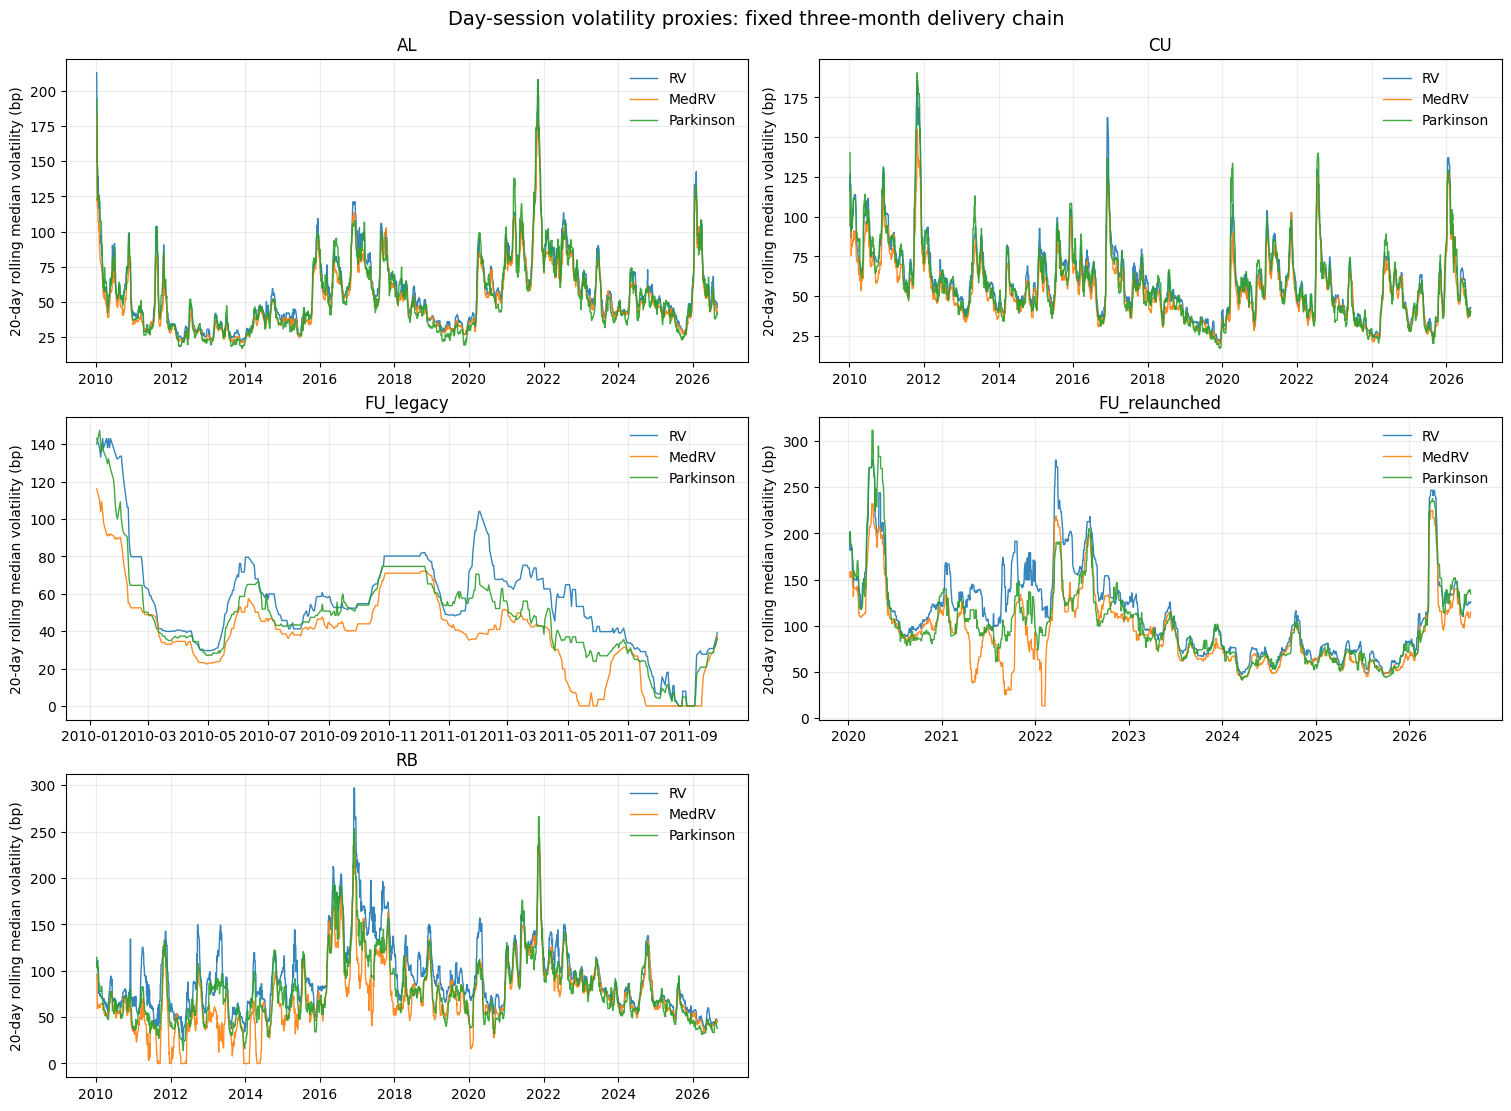

In [11]:
figure, axes = plt.subplots(3, 2, figsize=(15, 11), sharex=False, constrained_layout=True)
plot_color_by_proxy = {
    "RV": "#1f77b4",
    "MedRV": "#ff7f0e",
    "Parkinson": "#2ca02c",
}
for axis, series_id in zip(axes.flat, series_order):
    series_plot_df = volatility_proxy_df.loc[
        volatility_proxy_df["series_id"] == series_id,
        ["trading_date", *proxy_columns],
    ].set_index("trading_date")
    for proxy_column in proxy_columns:
        proxy_label = proxy_label_by_column[proxy_column]
        volatility_bps = 10_000 * np.sqrt(series_plot_df[proxy_column])
        rolling_volatility_bps = volatility_bps.rolling(20, min_periods=5).median()
        axis.plot(
            rolling_volatility_bps.index,
            rolling_volatility_bps,
            label=proxy_label,
            color=plot_color_by_proxy[proxy_label],
            linewidth=1.0,
            alpha=0.9,
        )
    axis.set_title(series_id)
    axis.set_ylabel("20-day rolling median volatility (bp)")
    axis.grid(alpha=0.25)
    axis.legend(loc="upper right", frameon=False)
axes.flat[-1].remove()
figure.suptitle("Day-session volatility proxies: fixed three-month delivery chain", fontsize=14)
plt.show()

## 9. 独立手工公式复核

下面选取首个有效 AL 合约日，独立用 45 个收益、43 个三元中位数及日内 high/low 重算三类代理。展示的首末槽 `three_return_median` 缺失是公式刻意排除 $n=1,N$，不是数据缺口。

In [12]:
manual_proxy_row = volatility_proxy_df.loc[
    (volatility_proxy_df["series_id"] == "AL")
    & volatility_proxy_df[proxy_columns].notna().all(axis=1)
].iloc[0]
manual_five_minute_df = five_minute_return_df.loc[
    (five_minute_return_df["series_id"] == manual_proxy_row["series_id"])
    & (five_minute_return_df["trading_date"] == manual_proxy_row["trading_date"]),
].copy()
manual_five_minute_df = manual_five_minute_df.sort_values("five_minute_slot", ignore_index=True)
manual_absolute_returns = manual_five_minute_df["five_minute_return"].abs().to_numpy()
manual_triplet_medians = np.median(
    np.column_stack(
        [
            manual_absolute_returns[:-2],
            manual_absolute_returns[1:-1],
            manual_absolute_returns[2:],
        ]
    ),
    axis=1,
)
manual_realized_variance = np.sum(manual_five_minute_df["five_minute_return"].to_numpy() ** 2)
manual_median_based_variance = medrv_total_multiplier * np.sum(manual_triplet_medians ** 2)
manual_range_based_variance = (
    np.log(manual_proxy_row["daily_high"] / manual_proxy_row["daily_low"]) ** 2
    / (4 * np.log(2))
)
manual_formula_audit_df = pd.DataFrame(
    {
        "proxy": proxy_order,
        "manual_value": [
            manual_realized_variance,
            manual_median_based_variance,
            manual_range_based_variance,
        ],
        "panel_value": [manual_proxy_row[column_name] for column_name in proxy_columns],
    }
)
manual_formula_audit_df["absolute_error"] = (
    manual_formula_audit_df["manual_value"] - manual_formula_audit_df["panel_value"]
).abs()

print(
    f"手工复核日: {manual_proxy_row['series_id']} {manual_proxy_row['trading_date'].date()} "
    f"{manual_proxy_row['contract_code']}；N={len(manual_five_minute_df)}；"
    f"MedRV 项数={len(manual_triplet_medians)}"
)
display(
    manual_five_minute_df[
        [
            "five_minute_slot",
            "first_bar_at",
            "last_bar_at",
            "five_minute_return",
            "previous_absolute_return",
            "absolute_return",
            "next_absolute_return",
            "three_return_median",
            "median_triplet_squared",
        ]
    ]
)
display(manual_formula_audit_df)

手工复核日: AL 2010-01-04 AL1004.XSGE；N=45；MedRV 项数=43


,five_minute_slot,first_bar_at,last_bar_at,five_minute_return,previous_absolute_return,absolute_return,next_absolute_return,three_return_median,median_triplet_squared
0,1,2010-01-04 09:01:00+08:00,2010-01-04 09:05:00+08:00,-5.173912e-03,NaN,5.173912e-03,9.264687e-03,NaN,NaN
1,2,2010-01-04 09:06:00+08:00,2010-01-04 09:10:00+08:00,-9.264687e-03,5.173912e-03,9.264687e-03,3.484324e-03,0.005174,2.676937e-05
2,3,2010-01-04 09:11:00+08:00,2010-01-04 09:15:00+08:00,3.484324e-03,9.264687e-03,3.484324e-03,2.026930e-03,0.003484,1.214051e-05
3,4,2010-01-04 09:16:00+08:00,2010-01-04 09:20:00+08:00,2.026930e-03,3.484324e-03,2.026930e-03,2.022830e-03,0.002027,4.108445e-06
4,5,2010-01-04 09:21:00+08:00,2010-01-04 09:25:00+08:00,2.022830e-03,2.026930e-03,2.022830e-03,2.594783e-03,0.002027,4.108445e-06
5,6,2010-01-04 09:26:00+08:00,2010-01-04 09:30:00+08:00,2.594783e-03,2.022830e-03,2.594783e-03,2.306141e-03,0.002306,5.318287e-06
6,7,2010-01-04 09:31:00+08:00,2010-01-04 09:35:00+08:00,-2.306141e-03,2.594783e-03,2.306141e-03,1.733103e-03,0.002306,5.318287e-06
7,8,2010-01-04 09:36:00+08:00,2010-01-04 09:40:00+08:00,-1.733103e-03,2.306141e-03,1.733103e-03,2.021661e-03,0.002022,4.087115e-06
8,9,2010-01-04 09:41:00+08:00,2010-01-04 09:45:00+08:00,2.021661e-03,1.733103e-03,2.021661e-03,8.659259e-04,0.001733,3.003645e-06
9,10,2010-01-04 09:46:00+08:00,2010-01-04 09:50:00+08:00,-8.659259e-04,2.021661e-03,8.659259e-04,5.225854e-17,0.000866,7.498276e-07


,proxy,manual_value,panel_value,absolute_error
0,RV,0.000193,0.000193,2.710505e-20
1,MedRV,0.000124,0.000124,0.000000e+00
2,Parkinson,0.000084,0.000084,0.000000e+00


## 10. 独立验证门禁

门禁同时覆盖数据边界、代理公式与输出性质。nullable OHLC 不被假设为必然完整：输出有效日必须精确等于各代理自身的局部公式资格日；有效值必须有限且非负。

In [13]:
sample_endpoint_audit_df = (
    volatility_proxy_df.groupby("series_id", observed=True)["trading_date"]
    .agg(observed_days="size", observed_start="min", observed_end="max")
    .reset_index()
    .merge(
        sample_spec_df[["series_id", "sample_start", "sample_end"]],
        on="series_id",
        validate="one_to_one",
    )
)
sample_endpoint_audit_df["start_matches"] = sample_endpoint_audit_df["observed_start"].eq(
    sample_endpoint_audit_df["sample_start"]
)
sample_endpoint_audit_df["end_matches"] = sample_endpoint_audit_df["observed_end"].eq(
    sample_endpoint_audit_df["sample_end"]
)

expected_complete_days = int(complete_contract_day_df["is_complete_contract_day"].sum())
expected_five_minute_rows = expected_complete_days * expected_five_minute_slots
expected_session_open_anchors = expected_complete_days * expected_day_sessions
return_eligible_days = int(volatility_proxy_df["return_proxy_eligible"].sum())
range_eligible_days = int(volatility_proxy_df["range_proxy_eligible"].sum())
rv_output_days = int(volatility_proxy_df["realized_variance"].notna().sum())
medrv_output_days = int(volatility_proxy_df["median_based_variance"].notna().sum())
range_output_days = int(volatility_proxy_df["range_based_variance"].notna().sum())
finite_proxy_values = proxy_long_df.loc[proxy_long_df["proxy_value"].notna(), "proxy_value"]
maximum_manual_formula_error = manual_formula_audit_df["absolute_error"].max()
maximum_stored_triplet_error = (
    manual_five_minute_df.loc[manual_five_minute_df["three_return_median"].notna(), "three_return_median"].to_numpy()
    - manual_triplet_medians
)
maximum_stored_triplet_error = np.max(np.abs(maximum_stored_triplet_error))
fu_legacy_last_date = volatility_proxy_df.loc[
    volatility_proxy_df["series_id"] == "FU_legacy", "trading_date"
].max()
fu_relaunched_first_date = volatility_proxy_df.loc[
    volatility_proxy_df["series_id"] == "FU_relaunched", "trading_date"
].min()

validation_gate_df = pd.DataFrame(
    [
        (
            "latitude_environment",
            current_python == expected_python,
            str(current_python),
        ),
        (
            "source_schema_physical_compatibility",
            source_contract_audit_df["physical_mismatch_count"].eq(0).all(),
            ", ".join(source_contract_audit_df["table_name"]),
        ),
        (
            "fixed_sample_endpoints",
            sample_endpoint_audit_df[["start_matches", "end_matches"]].all().all(),
            ", ".join(
                f"{row.series_id}:{row.observed_start.date()}..{row.observed_end.date()}"
                for row in sample_endpoint_audit_df.itertuples(index=False)
            ),
        ),
        (
            "unique_trade_month_plus_three_contract",
            contract_mapping_audit_df["target_contract_count"].isin([0, 1]).all()
            and contract_series_df["contract_code"].eq(contract_series_df["expected_contract_code"]).all()
            and actual_missing_keys_df.equals(known_missing_keys_df),
            "唯一固定三个月合约；仅排除 22 日 FU1102.XSGE 未上市缺口",
        ),
        (
            "day_session_and_minute_alignment",
            not contract_calendar_df["is_night_session"].any()
            and not bar_calendar_df["is_night_session"].any()
            and complete_contract_day_df["is_complete_contract_day"].all()
            and minute_read_audit_df["session_alignment_failures"].eq(0).all()
            and int(minute_read_audit_df["selected_day_minute_rows"].sum()) == expected_complete_days * expected_day_minutes,
            f"{expected_complete_days:,} 合约日；{int(minute_read_audit_df['selected_day_minute_rows'].sum()):,} 日盘分钟",
        ),
        (
            "session_open_return_anchors",
            int(minute_read_audit_df["session_open_anchors"].sum()) == expected_session_open_anchors,
            f"每个合约日 {expected_day_sessions} 个 Session 自身开盘锚，共 {expected_session_open_anchors:,}",
        ),
        (
            "five_minute_structure",
            len(five_minute_return_df) == expected_five_minute_rows
            and five_minute_return_df["actual_interval_minutes"].eq(five_minute_interval).all()
            and five_minute_return_df["session_span_count"].eq(1).all()
            and np.isfinite(five_minute_return_df["five_minute_return"]).all(),
            f"{len(five_minute_return_df):,} 个五分钟收益；每日日内 45 槽且不跨 Session",
        ),
        (
            "medrv_term_structure",
            volatility_proxy_df.loc[
                volatility_proxy_df["return_proxy_eligible"], "median_term_count"
            ].eq(expected_medrv_terms).all()
            and np.isclose(medrv_finite_sample_multiplier, 45 / 43),
            f"每日 {expected_medrv_terms} 项；有限样本修正 {medrv_finite_sample_multiplier:.12f}",
        ),
        (
            "proxy_output_matches_local_eligibility",
            rv_output_days == return_eligible_days
            and medrv_output_days == return_eligible_days
            and range_output_days == range_eligible_days,
            f"RV/MedRV {rv_output_days:,}/{medrv_output_days:,} 日；Parkinson {range_output_days:,} 日",
        ),
        (
            "proxy_values_finite_and_nonnegative",
            np.isfinite(finite_proxy_values).all() and finite_proxy_values.ge(0).all(),
            f"{len(finite_proxy_values):,} 个有效代理值；负值 0",
        ),
        (
            "manual_three_proxy_formulas",
            len(manual_five_minute_df) == expected_five_minute_slots
            and len(manual_triplet_medians) == expected_medrv_terms
            and maximum_stored_triplet_error < 1e-15
            and maximum_manual_formula_error < 1e-15,
            f"最大中位数项误差 {maximum_stored_triplet_error:.3e}；最大代理误差 {maximum_manual_formula_error:.3e}",
        ),
        (
            "fu_segments_are_independent",
            fu_legacy_last_date < fu_relaunched_first_date,
            f"legacy_end={fu_legacy_last_date.date()}, relaunched_start={fu_relaunched_first_date.date()}",
        ),
        (
            "rb_extension_is_separate",
            sample_spec_df.loc[sample_spec_df["series_id"] == "RB", "research_role"].eq("论文外扩展品种").all()
            and "RB" in volatility_proxy_df["series_id"].unique(),
            "RB 单列，不并入论文品种标签",
        ),
    ],
    columns=["gate", "passed", "evidence"],
)
display(sample_endpoint_audit_df)
display(validation_gate_df)
assert validation_gate_df["passed"].all(), validation_gate_df.loc[~validation_gate_df["passed"]]

,series_id,observed_days,observed_start,observed_end,sample_start,sample_end,start_matches,end_matches
0,AL,4045,2010-01-04,2026-08-28,2010-01-04,2026-08-28,True,True
1,CU,4045,2010-01-04,2026-08-28,2010-01-04,2026-08-28,True,True
2,FU_legacy,404,2010-01-04,2011-09-30,2010-01-04,2011-09-30,True,True
3,FU_relaunched,1614,2020-01-02,2026-08-28,2020-01-02,2026-08-28,True,True
4,RB,4045,2010-01-04,2026-08-28,2010-01-04,2026-08-28,True,True


,gate,passed,evidence
0,latitude_environment,True,E:\anaconda3\envs\latitude\python.exe
1,source_schema_physical_compatibility,True,"dim_futures_variety_calendar, dim_futures_contract_calendar, dim_futures_bar_calendar, fact_futures_minute"
2,fixed_sample_endpoints,True,"AL:2010-01-04..2026-08-28, CU:2010-01-04..2026-08-28, FU_legacy:2010-01-04..2011-09-30, FU_relaunched:2020-01-02..2026-08-28, RB:2010-01-04..2026-08-28"
3,unique_trade_month_plus_three_contract,True,唯一固定三个月合约；仅排除 22 日 FU1102.XSGE 未上市缺口
4,day_session_and_minute_alignment,True,"14,153 合约日；3,184,425 日盘分钟"
5,session_open_return_anchors,True,"每个合约日 3 个 Session 自身开盘锚，共 42,459"
6,five_minute_structure,True,"636,885 个五分钟收益；每日日内 45 槽且不跨 Session"
7,medrv_term_structure,True,每日 43 项；有限样本修正 1.046511627907
8,proxy_output_matches_local_eligibility,True,"RV/MedRV 14,153/14,153 日；Parkinson 14,153 日"
9,proxy_values_finite_and_nonnegative,True,"42,459 个有效代理值；负值 0"


## 11. 结果解释与限制

In [14]:
median_ratio_pivot_df = ratio_summary_df.pivot(
    index="series_id",
    columns="ratio",
    values="median",
).reindex(series_order)
minimum_pairwise_spearman = correlation_df.loc[
    correlation_df["method"] == "spearman", "correlation"
].min()
maximum_pairwise_spearman = correlation_df.loc[
    correlation_df["method"] == "spearman", "correlation"
].max()
minimum_proxy_coverage = proxy_coverage_df["coverage_pct"].min()
maximum_proxy_coverage = proxy_coverage_df["coverage_pct"].max()
source_high_below_low_rows = int(minute_read_audit_df["source_high_below_low_rows"].sum())

display(median_ratio_pivot_df.round(4))
display(
    Markdown(
        f"""
- 三类代理的有效覆盖率范围为 **{minimum_proxy_coverage:.4f}%–{maximum_proxy_coverage:.4f}%**；覆盖是按各公式自身的 OHLC 前提计算，而不是以填充换取完整面板。
- 五个序列、三组代理配对的 Spearman 相关系数范围为 **{minimum_pairwise_spearman:.4f}–{maximum_pairwise_spearman:.4f}**。共同上升表示它们捕捉相似的波动阶段；小于 1 则说明跳跃、零收益和区间信息会改变日度排序。
- `MedRV / RV` 的中位数反映局部中位数滤波后保留的连续型波动尺度；低于 1 常与孤立大收益对 RV 的贡献有关，但不能仅凭比率把差异全部解释为跳跃。
- `Parkinson / RV` 同时受日内价格区间、Session 内收益构造和经典扩散假设影响，不应机械期待等于 1。本项目只使用日盘范围，因此它不是包含夜盘或隔夜风险的全天方差。
- 来源分钟 `high < low` 行数为 **{source_high_below_low_rows:,}**；代码按数据库规范保留并报告来源值，不夹紧、不重写。Parkinson 只在 225 个 high/low 均有限、为正且聚合日范围有效时输出。
- 换月日保留 `is_roll_day`，但每个 Session 以自身 open 锚定，因此三代理都不包含跨日或跨合约价格跳空。FU 两个阶段没有跨停牌期连接，RB 仍是论文外扩展。
- 这些结果是 JQData 湖仓上的方法复现；样本、交易时段和品种构成不同，不能与论文 GTA 表格数值作逐项相等比较。
"""
    )
)

ratio,MedRV / RV,Parkinson / RV
series_id,,
AL,0.8726,0.8492
CU,0.8518,0.8969
FU_legacy,0.6028,0.6574
FU_relaunched,0.7826,0.7857
RB,0.7267,0.6856



- 三类代理的有效覆盖率范围为 **100.0000%–100.0000%**；覆盖是按各公式自身的 OHLC 前提计算，而不是以填充换取完整面板。
- 五个序列、三组代理配对的 Spearman 相关系数范围为 **0.7032–0.9563**。共同上升表示它们捕捉相似的波动阶段；小于 1 则说明跳跃、零收益和区间信息会改变日度排序。
- `MedRV / RV` 的中位数反映局部中位数滤波后保留的连续型波动尺度；低于 1 常与孤立大收益对 RV 的贡献有关，但不能仅凭比率把差异全部解释为跳跃。
- `Parkinson / RV` 同时受日内价格区间、Session 内收益构造和经典扩散假设影响，不应机械期待等于 1。本项目只使用日盘范围，因此它不是包含夜盘或隔夜风险的全天方差。
- 来源分钟 `high < low` 行数为 **0**；代码按数据库规范保留并报告来源值，不夹紧、不重写。Parkinson 只在 225 个 high/low 均有限、为正且聚合日范围有效时输出。
- 换月日保留 `is_roll_day`，但每个 Session 以自身 open 锚定，因此三代理都不包含跨日或跨合约价格跳空。FU 两个阶段没有跨停牌期连接，RB 仍是论文外扩展。
- 这些结果是 JQData 湖仓上的方法复现；样本、交易时段和品种构成不同，不能与论文 GTA 表格数值作逐项相等比较。
